Loading data...
Found: 6805 zeros, 0 negatives, 0 NaNs
  First zero: (Timestamp('2003-01-02 00:00:00'), 'CRM')
Data shape: (1517, 28)
Date range: 2019-03-20 00:00:00 to 2025-03-31 00:00:00

Fitting initial model...
Initial model converged in 17 iterations
Final log-likelihood: 52184.38
Spectral radii: 0.4696, 0.9040
Product of spectral radii: 0.4246


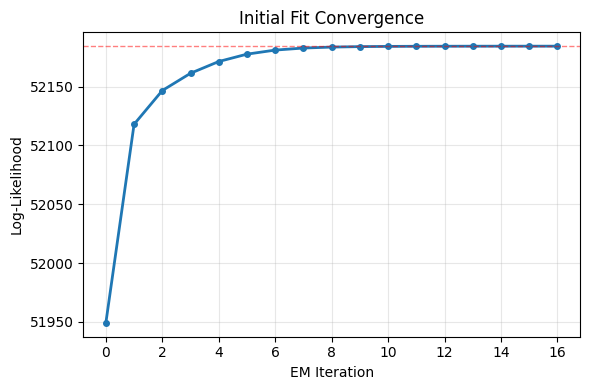

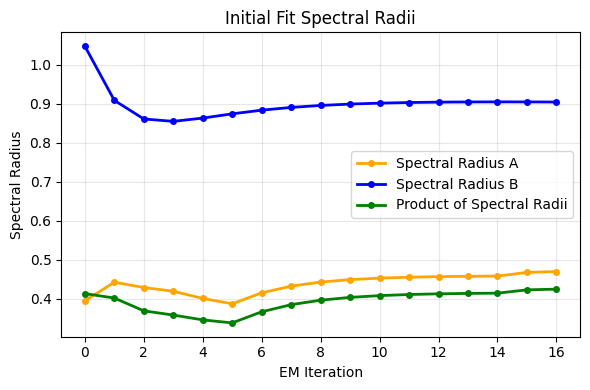

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.models import MAR
from src.trainer import ASSET_GRID
# =============================================================================
# 1. LOAD DATA
# =============================================================================
print("Loading data...")
dj_values = pd.read_excel("Dataset/dataset.xlsx", sheet_name="EoD_Prices", index_col=0)
dj_values.index = pd.to_datetime(dj_values.index)

# Scan for problematic values
zeros = (dj_values == 0).stack()
negs = (dj_values < 0).stack()
nans = dj_values.isna().stack()
if zeros.any() or negs.any() or nans.any():
    print(f"Found: {zeros.sum()} zeros, {negs.sum()} negatives, {nans.sum()} NaNs")
    if zeros.any(): print(f"  First zero: {zeros[zeros].index[0]}")
    if negs.any(): print(f"  First negative: {negs[negs].index[0]}")
    if nans.any(): print(f"  First NaN: {nans[nans].index[0]}")

# Extract log returns (suppress warnings, first row removed by .diff())
with np.errstate(divide='ignore', invalid='ignore'):
    df = np.log(dj_values).diff().dropna()

# Ensure we only have the columns in ASSET_GRID
all_assets = [asset for row in ASSET_GRID for asset in row]
df = df[all_assets]

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

# =============================================================================
# 2. FIT INITIAL MODEL TO CONVERGENCE
# =============================================================================
print("\nFitting initial model...")
model = MAR()

# Convert first 250 observations to matrix format (adjust context_length as needed)
from src.trainer import to_MAR_matrix
context_length = 252
initial_window = df.iloc[:context_length]
# de-mean the data
initial_window = initial_window - initial_window.mean()
X_initial = to_MAR_matrix(initial_window, mapping=ASSET_GRID)

# Initialize and fit to convergence
model.generate_starting_matrices(X_initial)
log_liks, iterations, rho_A_series, rho_B_series, _ = model.fit(X_initial, max_iter=100)
print(f"Initial model converged in {iterations} iterations")
print(f"Final log-likelihood: {log_liks[-1]:.2f}")
print(f"Spectral radii: {rho_A_series[-1]:.4f}, {rho_B_series[-1]:.4f}")
# compute spectral radius series: product of the two at each time step
spectral_radius_series = [a * b for a, b in zip(rho_A_series, rho_B_series)]
print(f"Product of spectral radii: {spectral_radius_series[-1]:.4f}")

# =============================================================================
# PLOT INITIAL FIT LOG-LIKELIHOOD
# =============================================================================
plt.figure(figsize=(6, 4))

plt.plot(log_liks, marker='o', linewidth=2, markersize=4)
plt.xlabel("EM Iteration")
plt.ylabel("Log-Likelihood")
plt.title("Initial Fit Convergence")
plt.grid(True, alpha=0.3)

final_ll = log_liks[-1]
plt.axhline(y=final_ll, color='r', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

# =============================================================================
# PLOT INITIAL FIT STABILITY SCORES
# =============================================================================
plt.figure(figsize=(6, 4))
plt.plot(rho_A_series, marker='o', linewidth=2, markersize=4, color='orange')
plt.plot(rho_B_series, marker='o', linewidth=2, markersize=4, color='blue')
plt.plot(spectral_radius_series, marker='o', linewidth=2, markersize=4, color='green')
plt.legend(["Spectral Radius A", "Spectral Radius B", "Product of Spectral Radii"])
plt.xlabel("EM Iteration")
plt.ylabel("Spectral Radius")
plt.title("Initial Fit Spectral Radii")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
from src.trainer import get_qdm_rolling
from typing import List
import src.loader as loader

# ————————————————————————————————————————————— #
# Parameters
step= 5
context_length = 252
initial_window = df.iloc[:context_length]
qdm_model = MAR()
# ————————————————————————————————————————————— #
# Import data
returns, volatilities, factors = loader.load_formatted_data()
selected = loader.screen_assets(
    returns, 
    top_n=15, 
    method="variance" # Options: 'variance', 'strength', 'max', 'nonzero'
)
print(f"Selected {len(selected)} assets: {selected}")
# Filter your data
returns_screened = returns[selected]
volatilities_screened = volatilities[selected]
# Compute QDM on screened returns
qdm, qdm_dates = get_qdm_rolling(returns_screened, context_length, 0.05,  return_end_dates=True)
qdm_batch = qdm[:, :, -context_length:]
qdm_batch = qdm_batch - qdm_batch.mean(axis=2, keepdims=True)

results: List[dict] = []
# ————————————————————————————————————————————— #

log_likelihoods, iters, rho_A_series, rho_B_series, rho_W_series = qdm_model.fit(
        qdm_batch, max_iter=100, patience=5
)  # it usually converges in ~10 iterations



context_length = 252
initial_window = df.iloc[:context_length]
# de-mean the data
initial_window = initial_window - initial_window.mean()
X_initial = to_MAR_matrix(initial_window, mapping=ASSET_GRID)

# Initialize and fit to convergence
model.generate_starting_matrices(X_initial)
log_liks, iterations, rho_A_series, rho_B_series, _ = model.fit(X_initial, max_iter=100)
print(f"Initial model converged in {iterations} iterations")
print(f"Final log-likelihood: {log_liks[-1]:.2f}")
print(f"Spectral radii: {rho_A_series[-1]:.4f}, {rho_B_series[-1]:.4f}")
# compute spectral radius series: product of the two at each time step
spectral_radius_series = [a * b for a, b in zip(rho_A_series, rho_B_series)]
print(f"Product of spectral radii: {spectral_radius_series[-1]:.4f}")



Loading data...
Selected 15 assets: ['JPM', 'AXP', 'GS', 'HON', 'DIS', 'MMM', 'CAT', 'BA', 'IBM', 'JNJ', 'CSCO', 'HD', 'CVX', 'PG', 'INTC']


Computing rolling QDM: 100%|██████████| 4975/4975 [00:06<00:00, 749.83it/s]


LinAlgError: 0-dimensional array given. Array must be at least two-dimensional